# NOBELOVE NAGRADE

Analiza o Nobelovih nagrajencih 

### UVOZ PODATKOV

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

nagrajenci = pd.read_csv("nobelovi_nagrajenci.csv", index_col="ime")
pd.options.display.max_rows = 20

### ANALIZA PO PODROČJIH

In [200]:
vsi = nagrajenci["področje_nagrade"]
kemija = nagrajenci["področje_nagrade"] == "Chemistry"
ekonomija = (
    nagrajenci["področje_nagrade"] == "Economic Sciences in Memory of Alfred Nobel"
)
literatura = nagrajenci["področje_nagrade"] == "Literature"
medicina_fiziologija = nagrajenci["področje_nagrade"] == "Physiology or Medicine"
mir = nagrajenci["področje_nagrade"] == "Peace"
fizika = nagrajenci["področje_nagrade"] == "Physics"

 Število vseh podeljenih nagrad in po posameznih področjih 

In [201]:
print(
    f"Število podeljenih nagrad: {vsi.count()}\n"
    f"Število podeljenih nagrad na področju kemije: {kemija.sum()}\n"
    f"Število podeljenih nagrad na področju ekonomije: {ekonomija.sum()}\n"
    f"Število podeljenih nagrad na področju literature: {literatura.sum()}\n"
    f"Število podeljenih nagrad na področju fiziologije ali medicine: {medicina_fiziologija.sum()}\n"
    f"Število podeljenih nagrad na področju miru: {mir.sum()}\n"
    f"Število podeljenih nagrad na področju fizike: {fizika.sum()}"
)

Število podeljenih nagrad: 1026
Število podeljenih nagrad na področju kemije: 200
Število podeljenih nagrad na področju ekonomije: 99
Število podeljenih nagrad na področju literature: 122
Število podeljenih nagrad na področju fiziologije ali medicine: 232
Število podeljenih nagrad na področju miru: 143
Število podeljenih nagrad na področju fizike: 230


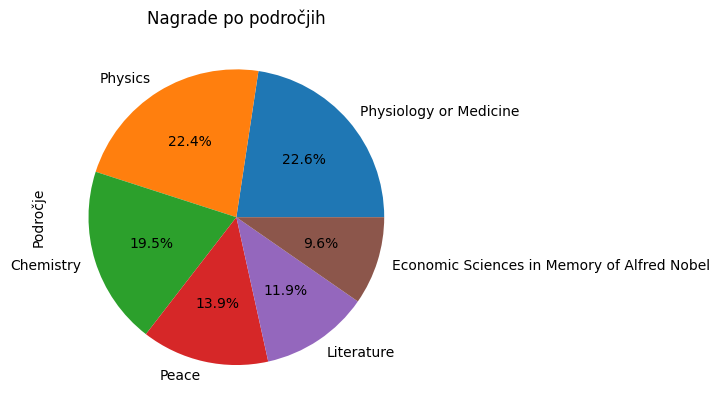

In [202]:
podrocja = nagrajenci["področje_nagrade"].value_counts()
graf = podrocja.plot.pie(
    ylabel="Področje", title="Nagrade po področjih", autopct="%1.1f%%"
)

In [203]:
odstrant = nagrajenci[nagrajenci["leto_rojstva"] == "/"]
podrocje_ni_oseba = odstrant["področje_nagrade"].value_counts()
ni_oseba = len(odstrant)
print(
    f"Število podeljenih nagrad, ki niso bile podeljene posameznikom znaša {ni_oseba} na področju {podrocje_ni_oseba.index[0]}."
)

Število podeljenih nagrad, ki niso bile podeljene posameznikom znaša 31 na področju Peace.


### ANALIZA LET NAGRADE 

In [204]:
leto_podelitve = nagrajenci["leto_nagrade"]
najvec_nagraj_leto = leto_podelitve.value_counts()
print(
    f"Leta {najvec_nagraj_leto.index[0]} je bilo podeljenih največ nagrad, in sicer {najvec_nagraj_leto.iloc[0]}."
)

Leta 2001 je bilo podeljenih največ nagrad, in sicer 15.


In [205]:
seznam_vseh_let = []
for let in range(1901, 2026):
    seznam_vseh_let.append(let)
for l in leto_podelitve:
    if l in seznam_vseh_let:
        seznam_vseh_let.remove(l)

brez_nagrad = ""
for leto1 in seznam_vseh_let:
    brez_nagrad += " "
    brez_nagrad += f"{str(leto1)},"
print(f"Leta{brez_nagrad} v katerih niso podelili Nobelovih nagrad.")

Leta 1940, 1941, 1942, v katerih niso podelili Nobelovih nagrad.


In [206]:
podrocje_nagra = "Chemistry"  # izberi področje nargarde
leto_podrocji = nagrajenci[nagrajenci["področje_nagrade"] == podrocje_nagra]
leto_podrocji1 = leto_podrocji["leto_nagrade"]
seznam_vseh_let_podrocja = []
for let in range(1901, 2026):
    seznam_vseh_let_podrocja.append(let)
for l in leto_podrocji1:
    if l in seznam_vseh_let_podrocja:
        seznam_vseh_let_podrocja.remove(l)

brez_nagrad = ""
for leto1 in seznam_vseh_let_podrocja:
    brez_nagrad += " "
    brez_nagrad += f"{str(leto1)},"
print(
    f"Leta{brez_nagrad} v katerih niso podelili Nobelovih nagrad na področju {podrocje_nagra}."
)

Leta 1916, 1917, 1919, 1924, 1933, 1940, 1941, 1942, v katerih niso podelili Nobelovih nagrad na področju Chemistry.


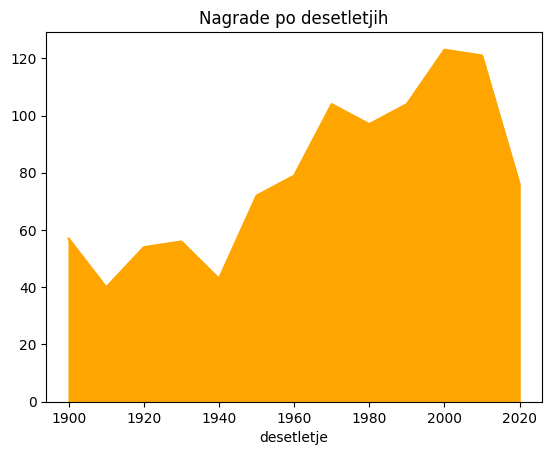

In [207]:
stevilo_nagrada = nagrajenci["leto_nagrade"]
desetletje = 10 * (stevilo_nagrada // 10)
graf_desetletja_nagrad = (
    desetletje.value_counts()
    .sort_index()
    .plot.area(xlabel="desetletje", color="orange", title="Nagrade po desetletjih")
)

### ANALIZA PO STAROSTI

Povprečna starost ob prejemu nagrad

In [208]:
leto_nagrade = nagrajenci["leto_nagrade"]

leto_rojstva = pd.to_numeric(nagrajenci["leto_rojstva"], errors="coerce")
nagrajenci["starost_ob_nagradi"] = leto_nagrade - leto_rojstva


print(
    f"Povprečna starost ob prejemu nagrade skupaj na vseh področjih znaša: {int(nagrajenci["starost_ob_nagradi"].mean())} let.\n"
    f"Povprečna starost ob prejemu nagrade na področju kemije znaša: {int(nagrajenci['starost_ob_nagradi'][kemija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrade na področju ekonomije znaša: {int(nagrajenci['starost_ob_nagradi'][ekonomija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrade na področju literature znaša: {int(nagrajenci['starost_ob_nagradi'][literatura].mean())} let\n"
    f"Povprečna starost ob prejemu nagrade na področju medicine ali fiziologije znaša: {int(nagrajenci['starost_ob_nagradi'][medicina_fiziologija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrade na področju miru znaša: {int(nagrajenci['starost_ob_nagradi'][mir].mean())} let\n"
    f"Povprečna starost ob prejemu nagrade na področju fizike znaša: {int(nagrajenci['starost_ob_nagradi'][fizika].mean())} let"
)

Povprečna starost ob prejemu nagrade skupaj na vseh področjih znaša: 60 let.
Povprečna starost ob prejemu nagrade na področju kemije znaša: 59 let
Povprečna starost ob prejemu nagrade na področju ekonomije znaša: 67 let
Povprečna starost ob prejemu nagrade na področju literature znaša: 64 let
Povprečna starost ob prejemu nagrade na področju medicine ali fiziologije znaša: 58 let
Povprečna starost ob prejemu nagrade na področju miru znaša: 60 let
Povprečna starost ob prejemu nagrade na področju fizike znaša: 57 let


In [209]:
najmlajsi = nagrajenci[
    nagrajenci["starost_ob_nagradi"] == min(nagrajenci["starost_ob_nagradi"])
]
najstarejsi = nagrajenci[
    nagrajenci["starost_ob_nagradi"] == max(nagrajenci["starost_ob_nagradi"])
]

najmlajsi1 = int(najmlajsi["starost_ob_nagradi"].iloc[0])
najstarejsi1 = int(najstarejsi["starost_ob_nagradi"].iloc[0])

print(
    f"Najmlajši prejemnik nagrade je bil/a {najmlajsi.index[0]}, ki je bil/a ob prejemu star/a {najmlajsi1} let.\n"
    f"Najstarejši prejemnik pa je bil/a {najstarejsi.index[0]}, ob prejemu star/a {najstarejsi1} let.\n"
    f"Starostna razlika med najstarejšim in najmlajšim prejemnikom nagrade znaša: {najstarejsi1-najmlajsi1} let."
)

Najmlajši prejemnik nagrade je bil/a Malala Yousafzai, ki je bil/a ob prejemu star/a 17 let.
Najstarejši prejemnik pa je bil/a John B. Goodenough, ob prejemu star/a 97 let.
Starostna razlika med najstarejšim in najmlajšim prejemnikom nagrade znaša: 80 let.


In [210]:
leto_nagrade = nagrajenci["leto_nagrade"]

leto_smrti = pd.to_numeric(nagrajenci["leto_smrti"], errors="coerce")
nagrajenci["število_let_po_nagradi"] = leto_smrti - leto_nagrade

povprecje = nagrajenci["število_let_po_nagradi"].mean()
print(f"Dobitniki po prejemu nagarade v povprečju živijo še {int(povprecje)} let.")

Dobitniki po prejemu nagarade v povprečju živijo še 21 let.


### ANALIZA PO MESECIH 

Nagrajenci, ki so se rodili in umrli na isti dan

In [211]:
filtrira_posevnice = nagrajenci[
    (nagrajenci["dan_smrti"] != "/") & (nagrajenci["datum_rojstva"] != "/")
]

filtrira_posevnice[
    filtrira_posevnice["dan_smrti"] == filtrira_posevnice["datum_rojstva"]
]

,datum_rojstva,leto_rojstva,država_rojstva,dan_smrti,leto_smrti,država_smrti,področje_nagrade,leto_nagrade,starost_ob_nagradi,število_let_po_nagradi
ime,,,,,,,,,,
Walter Norman Haworth,19 March,1883,United Kingdom,19 March,1950,United Kingdom,Chemistry,1937,54.0,13.0
Thomas A. Steitz,23 August,1940,USA,23 August,2018,USA,Chemistry,2009,69.0,9.0


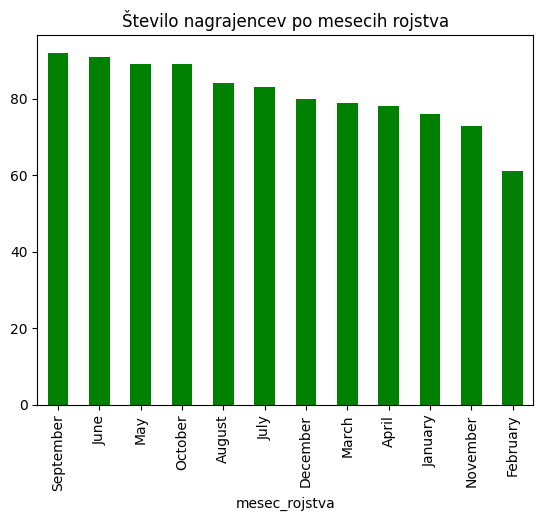

In [212]:
datum_rojstva = nagrajenci[nagrajenci["datum_rojstva"] != "/"]
nagrajenci[["dan_rojstva", "mesec_rojstva"]] = nagrajenci["datum_rojstva"].str.extract(
    r"(\d+ )([a-zA-Z]+)"
)
po_mesecih_rojstva = nagrajenci["mesec_rojstva"].value_counts()
graf_mesecev = po_mesecih_rojstva.plot.bar(
    title="Število nagrajencev po mesecih rojstva", color="green"
)

In [213]:
zelen_datum = "2 March"  # izbereš datum rojstva
zelen_rojstvo = nagrajenci[nagrajenci["datum_rojstva"] == zelen_datum]
v_niz = ", ".join(zelen_rojstvo.index)

zelen_smrt = nagrajenci[nagrajenci["dan_smrti"] == zelen_datum]
v_niz_smrt = ", ".join(zelen_smrt.index)

if v_niz_smrt != "" and v_niz != "":
    print(
        f"Na {zelen_datum} se/sta/so je/se rodil/a/i {v_niz} in umrl/a/i {v_niz_smrt}."
    )
elif v_niz_smrt == "" and v_niz != "":
    print(
        f"Na {zelen_datum} se/sta/so je/se rodil/a/i {v_niz} in nihče ni umrl na ta datum."
    )
elif v_niz == "" and v_niz_smrt != "":
    print(f"Na {zelen_datum} se ni rodil nihče in umrl/a/i {v_niz_smrt}.")
else:
    print(f"Na {zelen_datum} se ni nihče od nagrajencev rodil in ni nihče umrl.")

Na 2 March se/sta/so je/se rodil/a/i Mikhail Sergeyevich Gorbachev in nihče ni umrl na ta datum.


### ANALIZA PO DRŽAVAH

Od kod prihaja največ nagrajencev oziroma v kateri državi se je rodilo največ nagrajencev

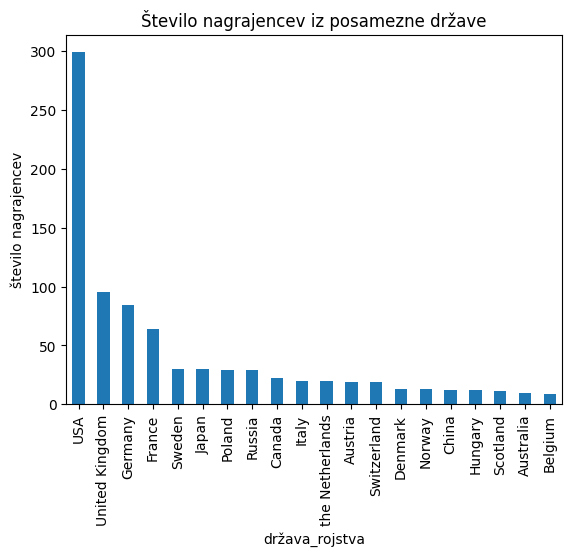

In [214]:
drzava_brez_pomisl = nagrajenci[nagrajenci["država_rojstva"] != "/"]
drzave_po_nagrajencih = drzava_brez_pomisl["država_rojstva"].value_counts()


drzave_graf = drzave_po_nagrajencih.head(20).plot.bar(
    ylabel="število nagrajencev", title="Število nagrajencev iz posamezne države"
)

Koliko in kam so se preselili Nobelovi nagrajenci

In [215]:
drzave_selitve = nagrajenci[
    (nagrajenci["država_rojstva"] != "/")
    & (nagrajenci["država_smrti"] != "/")
    & (nagrajenci["država_rojstva"] != nagrajenci["država_smrti"])
]

print(
    f"Število nagrajencev, ki se je rodilo v drugi državi, kot je umrlo, znaša: {len(drzave_selitve)}."
)

Število nagrajencev, ki se je rodilo v drugi državi, kot je umrlo, znaša: 215.


In [216]:
najveckrat_drzava_selitve = drzave_selitve["država_smrti"].value_counts()

drzava_najveckrat = najveckrat_drzava_selitve.index[0]
iz_katre_drzave_preselili = drzave_selitve[
    (drzave_selitve["država_smrti"] == drzava_najveckrat)
]
najveckrat_rojstvo = iz_katre_drzave_preselili["država_rojstva"].value_counts()

print(
    f"Nobelovi nagrajenci so se največkrat preselili v {drzava_najveckrat}.\n"
    f"Največ Nobelovih nagrajencev se je preselilo iz {najveckrat_rojstvo.index[0]} v {drzava_najveckrat}."
)

Nobelovi nagrajenci so se največkrat preselili v USA.
Največ Nobelovih nagrajencev se je preselilo iz Germany v USA.


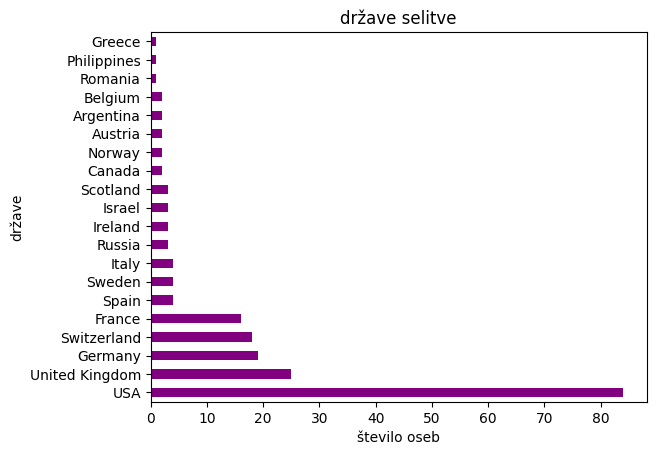

In [217]:
graf_drzav_selitev = najveckrat_drzava_selitve.head(20).plot.barh(
    title="države selitve", color="purple"
)
yos = plt.ylabel("države")
xos = plt.xlabel("število oseb")

Koliko nagrajencev prihaja iz točno določene države

In [218]:
drzava = "Slovenia"  # izbereš želeno državo rojstva
drzave_sez = []
for i in nagrajenci["država_rojstva"]:
    if i not in drzave_sez:
        drzave_sez.append(i)

if drzava in drzave_sez:
    stevilo = nagrajenci[nagrajenci["država_rojstva"] == drzava]

    if stevilo["država_rojstva"].value_counts().iloc[0] == 1:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država_rojstva'].value_counts().iloc[0]} oseba, in sicer {stevilo['država_rojstva'].index[0]}."
        )
    elif stevilo["država_rojstva"].value_counts().iloc[0] == 2:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država_rojstva'].value_counts().iloc[0]} osebi, in sicer {", ".join(stevilo.index)}."
        )
    elif stevilo["država_rojstva"].value_counts().iloc[0] > 2:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država_rojstva'].value_counts().iloc[0]} oseb, in sicer {", ".join(stevilo.index)}."
        )
else:
    print(f"{drzava} nima nobenega nagrajenca.")

Iz Slovenia je prejelo Nobelovo nagrado 1 oseba, in sicer Fritz Pregl.


### ANALIZA PO LETIH ROJSTVA

In [219]:
najvec = nagrajenci[nagrajenci["leto_rojstva"] != "/"]
najvec_rojs = najvec["leto_rojstva"].value_counts()

najvec_smrti = nagrajenci[nagrajenci["leto_smrti"] != "/"]
najvec_smr = najvec_smrti["leto_smrti"].value_counts()

print(
    f"Največ nagrajencev se je rodilo leta {najvec_rojs.index[0]}, in sicer {najvec_rojs.iloc[0]}.\n"
    f"Največ nagrajencev je umrlo leta {najvec_smr.index[0]}, in sicer {najvec_smr.iloc[0]}."
)

Največ nagrajencev se je rodilo leta 1918, in sicer 23.
Največ nagrajencev je umrlo leta 2013, in sicer 19.


Število nagrajencev po njihovih desetletjih rojstva

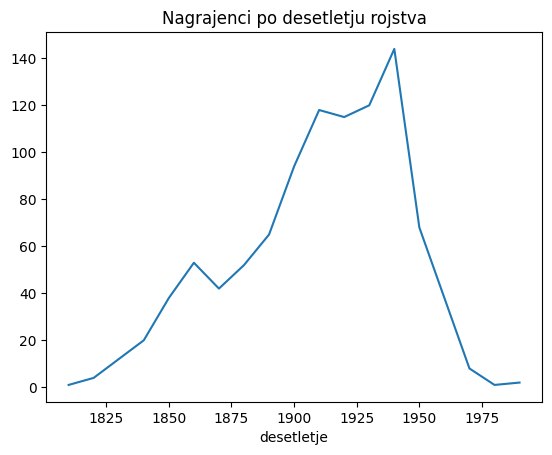

In [220]:
rojstvo_l = nagrajenci[nagrajenci["leto_rojstva"] != "/"]

v_stevilko = rojstvo_l["leto_rojstva"].astype(int)
desetlet = 10 * (v_stevilko // 10)
graf_desetletja_rojstev = (
    desetlet.value_counts()
    .sort_index()
    .plot(xlabel="desetletje", title="Nagrajenci po desetletju rojstva")
)